# APRENDIZAJE AUTOMÁTICO
# Práctica 5: Clasificación bayesiana
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 06-03-2026
---

---
## 0. Carga de datos de MNIST

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load data from https://www.openml.org/
dataset = "mnist_784"
X, y = fetch_openml(dataset, version=1, return_X_y=True, as_frame=False, parser="pandas")
X = X / 255.0  # Escalar los datos entre 0 y 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, shuffle=False)

print('X_train.shape:', X_train.shape)
print('y_train.shape:', y_train.shape)
print('X_test.shape:', X_test.shape)
print('y_test.shape:', y_test.shape)


X_train.shape: (60000, 784)
y_train.shape: (60000,)
X_test.shape: (10000, 784)
y_test.shape: (10000,)


.......

## Calcular medias clases.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

clases = np.unique(y_train)
clase_objetivo = "3"

medias_clase = {clase: np.mean(X_train[y_train == clase], axis=0) for clase in clases}
varianzas_clase = {clase: np.var(X_train[y_train == clase], axis=0) for clase in clases}


## Calcular varianzas clases.

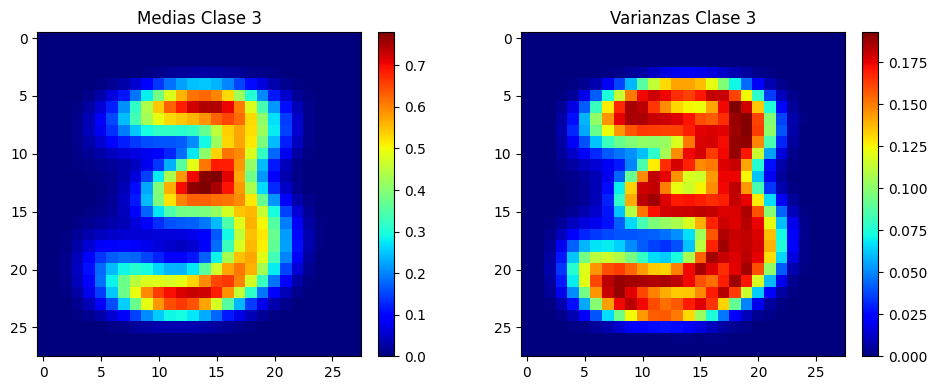

In [3]:
media_clase_3 = medias_clase[clase_objetivo].reshape(28, 28)
varianza_clase_3 = varianzas_clase[clase_objetivo].reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(media_clase_3, cmap="jet")
axes[0].set_title("Medias Clase 3")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(varianza_clase_3, cmap="jet")
axes[1].set_title("Varianzas Clase 3")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Bayes ingenuo

In [4]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X_train, y_train)
accuracy_train = accuracy_score(y_train, clf.predict(X_train))
print(f'Accuracy en entrenamiento: {accuracy_train:.4f}')

Accuracy en entrenamiento: 0.5649


Mejor var_smoothing: 4.8e-02
Mejor Accuracy en validacion cruzada: 0.8002
Mejor Accuracy en test: 0.8130


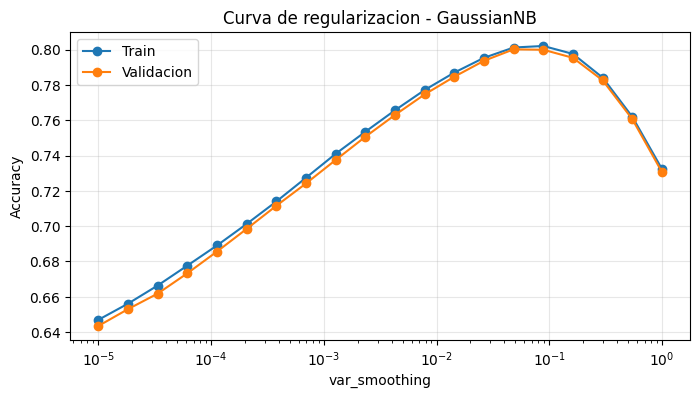

In [5]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
valoresSmooth = np.logspace(-5,0,20)
# Añadido para ver los warnings y la imposibilidad de usar var_smoothing=0
valoresSmooth = np.append(valoresSmooth, [0])

grid_gaussian = GridSearchCV(
    estimator=GaussianNB(),
    param_grid={"var_smoothing": valoresSmooth},
    scoring="accuracy",
    cv=5,
    return_train_score=True,
    n_jobs=4,
)

grid_gaussian.fit(X_train, y_train)
resultados_gaussian = pd.DataFrame(grid_gaussian.cv_results_)
resultados_gaussian = resultados_gaussian[resultados_gaussian["param_var_smoothing"] > 0].copy()
resultados_gaussian["var_smoothing"] = resultados_gaussian["param_var_smoothing"].astype(float)
resultados_gaussian = resultados_gaussian.sort_values("var_smoothing")

print(f'Mejor var_smoothing: {grid_gaussian.best_params_["var_smoothing"]:.1e}')
print(f'Mejor Accuracy en validacion cruzada: {grid_gaussian.best_score_:.4f}')
y_pred = grid_gaussian.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Mejor Accuracy en test: {accuracy:.4f}')

plt.figure(figsize=(8, 4))
plt.semilogx(resultados_gaussian["var_smoothing"], resultados_gaussian["mean_train_score"], marker="o", label="Train")
plt.semilogx(resultados_gaussian["var_smoothing"], resultados_gaussian["mean_test_score"], marker="o", label="Validacion")
plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")
plt.title("Curva de regularizacion - GaussianNB")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


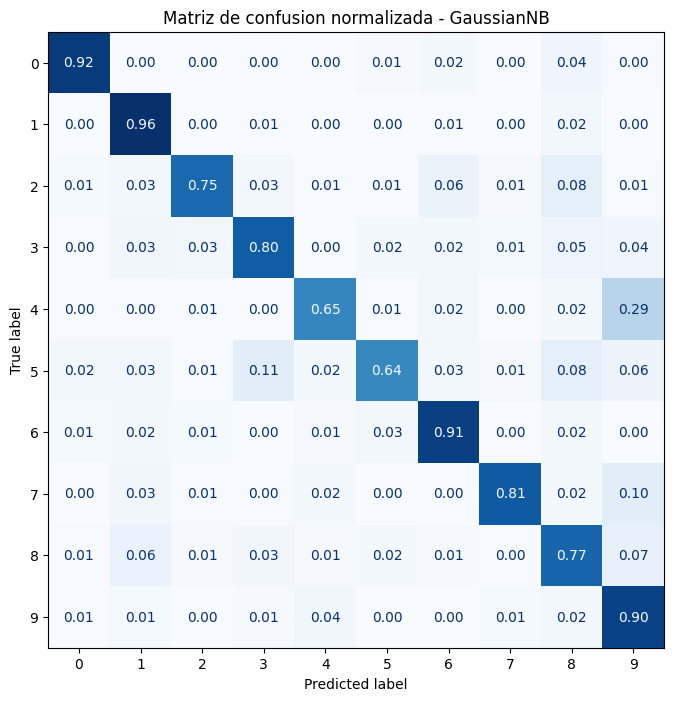

Digitos mas problematicos (menor recall):
- Digito 5: recall=0.6390
- Digito 4: recall=0.6466
- Digito 2: recall=0.7539

Confusiones mas habituales (porcentaje sobre el digito real):
- 4 -> 9: 28.62%
- 5 -> 3: 10.54%
- 7 -> 9: 10.31%
- 2 -> 8: 8.43%
- 5 -> 8: 8.41%
- 8 -> 9: 7.49%
- 8 -> 1: 6.47%
- 2 -> 6: 6.20%


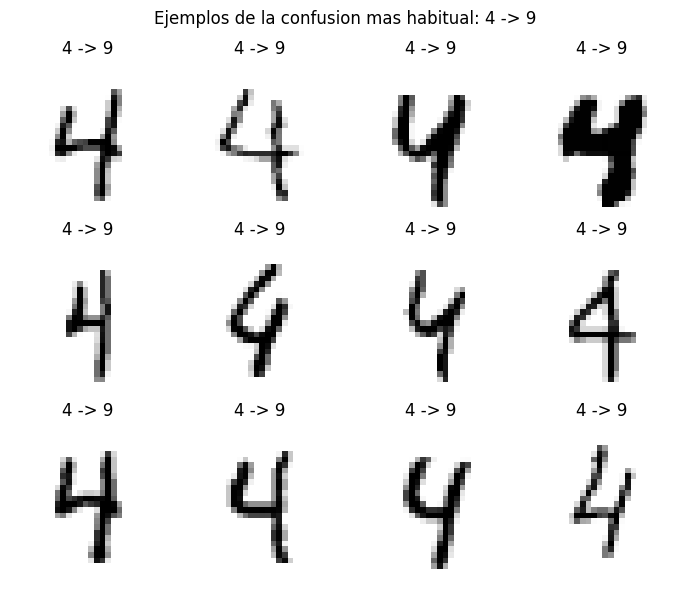

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pandas as pd

y_pred_test_gau = grid_gaussian.predict(X_test)
accuracy_test_gau = accuracy_score(y_test, y_pred_test_gau)

labels = np.array(grid_gaussian.best_estimator_.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_gau, labels=labels, normalize="true")


fig, ax = plt.subplots(figsize=(8, 8))
dispConfMatrix = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
dispConfMatrix.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - GaussianNB")
plt.show()
    
recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_gau == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_gau[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones del modelo gaussiano ingenuo.

No llegamos a ver sobreajuste porque estamos usando todos los datos del dataset para entrenar (80%).

Este modelo asume que los píxeles son independientes entre ellos, es decir, que haya un pixel en la posición [20,20] no afecta a la probabilidad
de que haya otro pixel en la posición [20,21] (lo cual obviamente no es cierto).

Vemos que está suposición / simplificación para nuestro dataset tiene un gran efecto a la hora de clasificar correctamente los modelos y generar 
la línea de separación.

Los resultados son ciertamente muy malos, teniendo un recall de $0.63$ y $0.64$ en los números $5$ y $4$ respectivamente.

Al igual que un $81$% de Accuracy en los datos de test. 

## LDA

Valores de shrinkage a probar: ['auto', np.float64(1e-07), np.float64(0.0416667625), np.float64(0.083333425), np.float64(0.1250000875), np.float64(0.16666675), np.float64(0.2083334125), np.float64(0.250000075), np.float64(0.2916667375), np.float64(0.3333334), np.float64(0.3750000625), np.float64(0.416666725), np.float64(0.4583333875), np.float64(0.5000000499999999), np.float64(0.5416667125), np.float64(0.5833333749999999), np.float64(0.6250000375), np.float64(0.6666667), np.float64(0.7083333624999999), np.float64(0.750000025), np.float64(0.7916666874999999), np.float64(0.83333335), np.float64(0.8750000124999999), np.float64(0.916666675), np.float64(0.9583333374999999), np.float64(1.0)]
Mejor combinación de parámetros: {'shrinkage': np.float64(0.4583333875), 'solver': 'lsqr'}
Mejor Accuracy en validacion cruzada: 0.8723
Accuracy en test: 0.8799


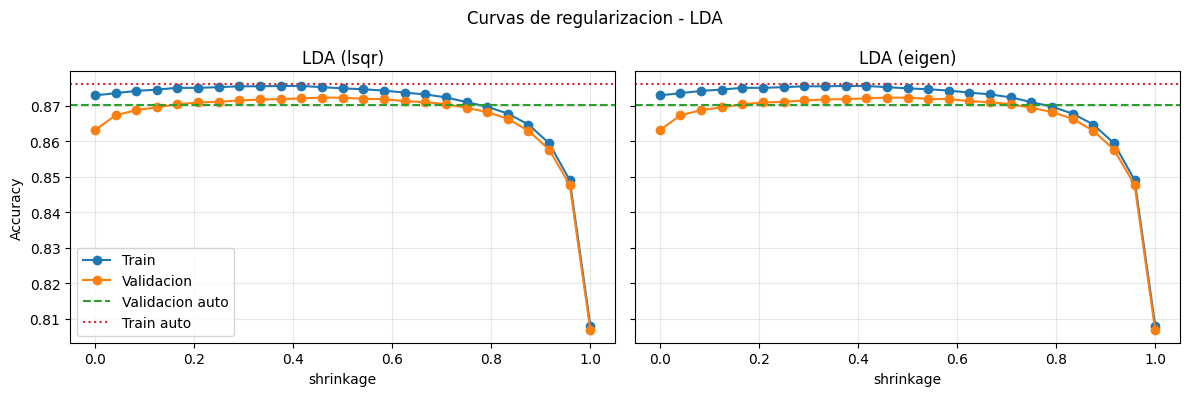

In [7]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

shrinkage_values = ['auto'] + list(np.linspace(0.0000001, 1, 25))

print("Valores de shrinkage a probar:", shrinkage_values)

grid_lda = GridSearchCV(
    estimator=LinearDiscriminantAnalysis(
        tol=0.01,
    ),
    param_grid={"solver": ["lsqr", "eigen"], "shrinkage": shrinkage_values},
    scoring="accuracy",
    cv=5,
    return_train_score=True,
    n_jobs=4,
)

grid_lda.fit(X_train, y_train)
resultados_lda = pd.DataFrame(grid_lda.cv_results_)
resultados_lda_num = resultados_lda[resultados_lda["param_shrinkage"] != "auto"].copy()
resultados_lda_num["shrinkage"] = resultados_lda_num["param_shrinkage"].astype(float)
resultados_lda_num = resultados_lda_num.sort_values(["param_solver", "shrinkage"])
resultados_lda_auto = resultados_lda[resultados_lda["param_shrinkage"] == "auto"].copy()

print(f'Mejor combinación de parámetros: {grid_lda.best_params_}')
print(f'Mejor Accuracy en validacion cruzada: {grid_lda.best_score_:.4f}')
y_pred_lda = grid_lda.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f'Accuracy en test: {accuracy_lda:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, solver in zip(axes, ["lsqr", "eigen"]):
    datos_solver = resultados_lda_num[resultados_lda_num["param_solver"] == solver]
    auto_solver = resultados_lda_auto[resultados_lda_auto["param_solver"] == solver]

    ax.plot(datos_solver["shrinkage"], datos_solver["mean_train_score"], marker="o", label="Train")
    ax.plot(datos_solver["shrinkage"], datos_solver["mean_test_score"], marker="o", label="Validacion")

    if not auto_solver.empty:
        ax.axhline(auto_solver["mean_test_score"].iloc[0], color="tab:green", linestyle="--", label="Validacion auto")
        ax.axhline(auto_solver["mean_train_score"].iloc[0], color="tab:red", linestyle=":", label="Train auto")

    ax.set_title(f"LDA ({solver})")
    ax.set_xlabel("shrinkage")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend()
fig.suptitle("Curvas de regularizacion - LDA")
plt.tight_layout()
plt.show()


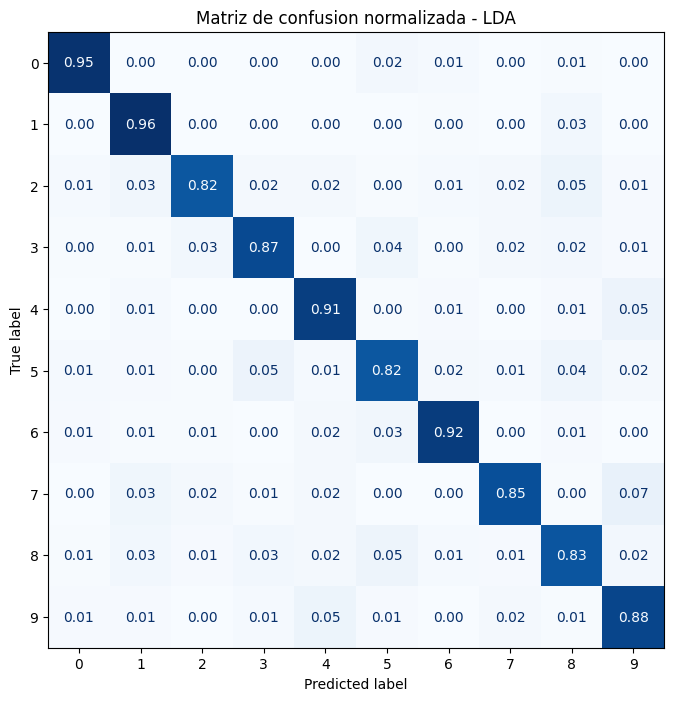

Digitos mas problematicos (menor recall):
- Digito 2: recall=0.8169
- Digito 5: recall=0.8184
- Digito 8: recall=0.8255

Confusiones mas habituales (porcentaje sobre el digito real):
- 7 -> 9: 7.10%
- 4 -> 9: 5.50%
- 5 -> 3: 5.27%
- 2 -> 8: 5.04%
- 9 -> 4: 4.96%
- 8 -> 5: 4.52%
- 5 -> 8: 4.26%
- 3 -> 5: 3.66%


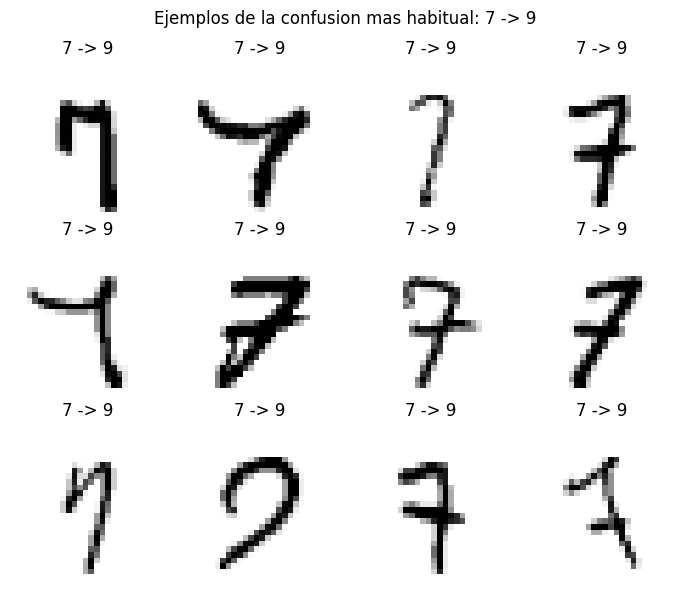

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pandas as pd

y_pred_test_lda = grid_lda.predict(X_test)
accuracy_test_lda = accuracy_score(y_test, y_pred_test_lda)

labels = np.array(grid_lda.best_estimator_.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_lda, labels=labels, normalize="true")


fig, ax = plt.subplots(figsize=(8, 8))
dispConfMatrix = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
dispConfMatrix.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - LDA")
plt.show()
    
recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_lda == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_lda[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones modelo LDA

No llegamos a ver sobreajuste porque estamos usando todos los datos del dataset para entrenar (80%).

Este modelo lo que hace es que calcula 1 matriz de covarianza y asume que todas las variables tienen la misma matriz de covarianza, lo cual es una mejora muy
considerable respecto a la suposición de independencia de variables.

Vemos como los valores terribles de recall de los números mejoran considerablemente, unos 20 puntos, siendo ahora los peores recalls $0.81$ y está vez para los dígitos $2$ y $5$.

Sin embargo, el Accuracy no cambia tanto, asciende al $87$% en los datos de test.
Aún así, la mejora respecto al modelo anterior es bastante considerable.

## Bayes completo (QDA)

Mejor combinación de parámetros: {'reg_param': np.float64(0.1), 'solver': 'svd'}
Mejor Accuracy en validacion cruzada: 0.9520
Accuracy en test: 0.9570


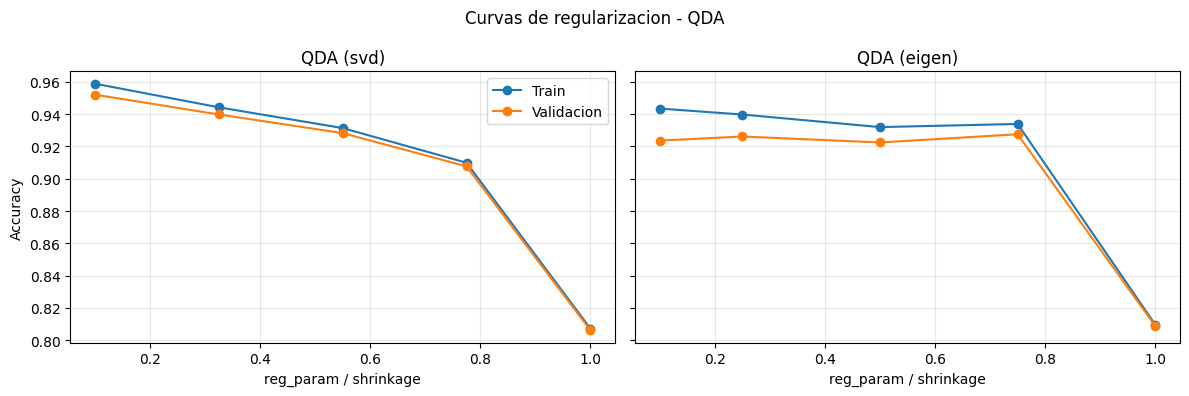

In [9]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

reg_param_values_qda = np.linspace(0.1, 1.0, 5)
shrinkage_values_qda = [0.1, 0.25, 0.5, 0.75, 1.0]

param_grid_qda = [
    {"solver": ["svd"], "reg_param": reg_param_values_qda},
    {"solver": ["eigen"], "shrinkage": shrinkage_values_qda},
]

grid_qda = GridSearchCV(
    estimator=QuadraticDiscriminantAnalysis(),
    param_grid=param_grid_qda,
    scoring="accuracy",
    cv=5,
    return_train_score=True,
    n_jobs=4,
)

grid_qda.fit(X_train, y_train)
resultados_qda = pd.DataFrame(grid_qda.cv_results_)

# Unify x-axis parameter for plotting: reg_param for svd and shrinkage for eigen
resultados_qda["reg_param"] = pd.to_numeric(resultados_qda.get("param_reg_param"), errors="coerce")
resultados_qda["shrinkage_num"] = pd.to_numeric(resultados_qda.get("param_shrinkage"), errors="coerce")
resultados_qda["x_plot"] = resultados_qda["reg_param"].fillna(resultados_qda["shrinkage_num"])
resultados_qda = resultados_qda.sort_values(["param_solver", "x_plot"])

print(f'Mejor combinación de parámetros: {grid_qda.best_params_}')
print(f'Mejor Accuracy en validacion cruzada: {grid_qda.best_score_:.4f}')
y_pred_qda = grid_qda.predict(X_test)
accuracy_qda = accuracy_score(y_test, y_pred_qda)
print(f'Accuracy en test: {accuracy_qda:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, solver in zip(axes, ["svd", "eigen"]):
    datos_solver = resultados_qda[resultados_qda["param_solver"] == solver].copy()
    if solver == "eigen":
        datos_solver = datos_solver[datos_solver["param_shrinkage"] != "auto"].copy()

    ax.plot(datos_solver["x_plot"], datos_solver["mean_train_score"], marker="o", label="Train")
    ax.plot(datos_solver["x_plot"], datos_solver["mean_test_score"], marker="o", label="Validacion")
    ax.set_title(f"QDA ({solver})")
    ax.set_xlabel("reg_param / shrinkage")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend()
fig.suptitle("Curvas de regularizacion - QDA")
plt.tight_layout()
plt.show()



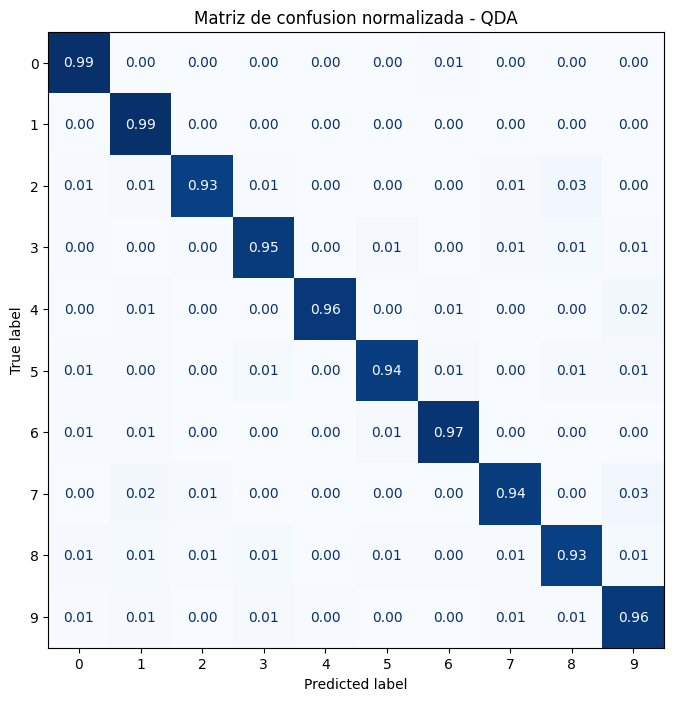

Digitos mas problematicos (menor recall):
- Digito 8: recall=0.9281
- Digito 2: recall=0.9312
- Digito 5: recall=0.9395

Confusiones mas habituales (porcentaje sobre el digito real):
- 7 -> 9: 2.72%
- 2 -> 8: 2.62%
- 4 -> 9: 1.93%
- 7 -> 1: 1.85%
- 3 -> 8: 1.49%
- 5 -> 3: 1.46%
- 8 -> 3: 1.44%
- 8 -> 1: 1.33%


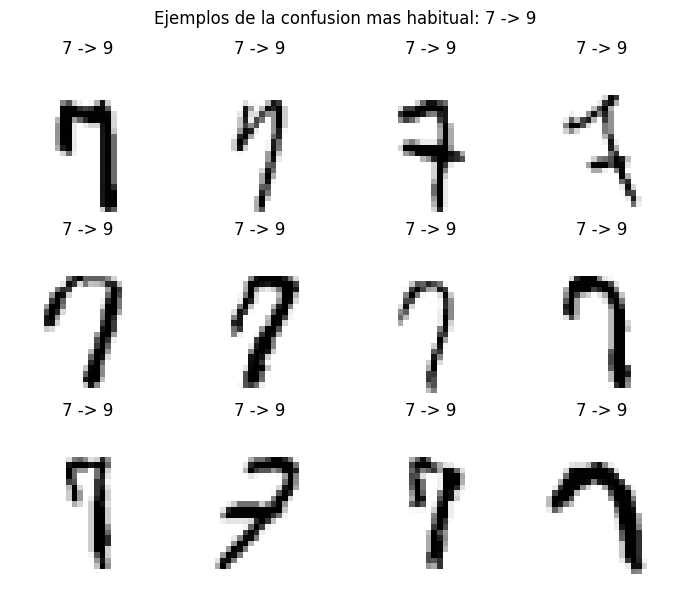

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pandas as pd

y_pred_test_qda = grid_qda.predict(X_test)
accuracy_test_qda = accuracy_score(y_test, y_pred_test_qda)

labels = np.array(grid_qda.best_estimator_.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_qda, labels=labels, normalize="true")


fig, ax = plt.subplots(figsize=(8, 8))
dispConfMatrix = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
dispConfMatrix.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - QDA")
plt.show()
    
recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_qda == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_qda[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones de Bayes Completo

No llegamos a ver sobreajuste porque estamos usando todos los datos del dataset para entrenar (80%).

Este modelo hace menos suposiciones, dado que calcula la matriz de covarianza para cada variable, lo cual en un principio, nos da mucha mayor precisión a coste de un mayor tiempo
de ejecución.

Al igual que la posibilidad de la existencia del sobreajuste, que se puede producir al haber muchos sobreajuste. Aunque esto no produce realmente ningún problema para este caso, porque
tenemos muchos datos, lo que regula mucho el modelo.

Esto se puede observar en nuestras gráficas, dado que en los 5 valores que se han probado, el mejor de ellos para cada solver de los 2 usados, el mejor valor del parámetro
regulador han sido con los valores más bajos.

Vemos como al aumentar la regulación (hace que los valores de matriz covarianza sean todos más similares porque suman valores a todos los elementos de la matriz, haciendo la diferencia entre la diagonal principal, y el resto de componentes de correlación sea menor), distingue mucho peor, y al aumentar la regularización a 1, el Accuracy cae en picado (con la escala representada, sigue siendo mejor que Bayes Ingenuo).

Ahora si observamos un buen modelo, aunque la Regresión Logística bien ajustada o una buena red neuronal sigue siendo superior.

## Comparación de modelos:

### Learning curves

Comparacion de curvas de aprendizaje usando los mejores modelos bayesianos de esta practica y la regresion logistica de la practica anterior.


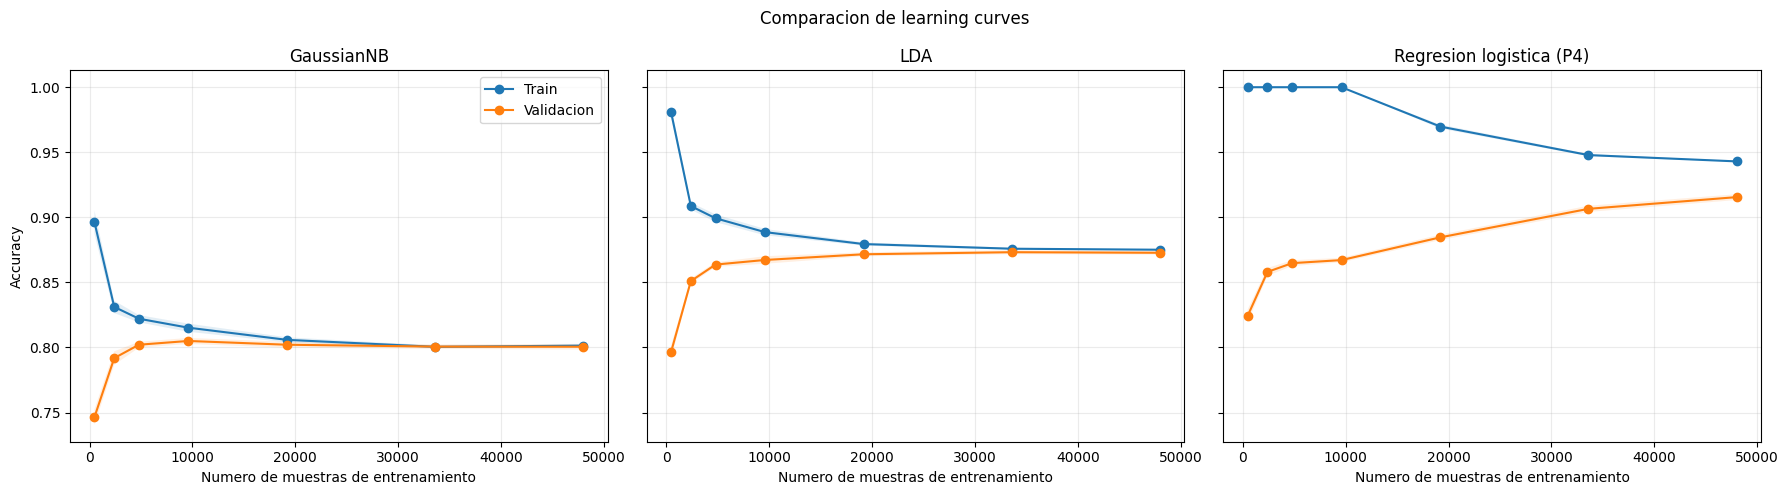

Accuracy medio de validacion por tamano y modelo:
modelo      GaussianNB     LDA  Regresion logistica (P4)
train_size                                              
480             0.7465  0.7965                    0.8243
2400            0.7918  0.8510                    0.8581
4800            0.8021  0.8637                    0.8648
9600            0.8050  0.8672                    0.8672
19200           0.8021  0.8716                    0.8846
33600           0.8007  0.8732                    0.9065
48000           0.8006  0.8728                    0.9155


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, learning_curve

cv_learning = StratifiedKFold(n_splits=5, shuffle=True, random_state=28)
train_sizes = np.array([0.01, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0])

modelos_learning = {
    "GaussianNB": grid_gaussian.best_estimator_,
    "LDA": grid_lda.best_estimator_,
    "Regresion logistica (P4)": LogisticRegression(
        penalty=None,
        max_iter=300,
        random_state=28,
    ),
}

fig, axes = plt.subplots(1, len(modelos_learning), figsize=(18, 5), sharey=True)
resultados_learning = []

for ax, (nombre, estimador) in zip(axes, modelos_learning.items()):
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimador,
        X=X_train,
        y=y_train,
        train_sizes=train_sizes,
        cv=cv_learning,
        scoring="accuracy",
        n_jobs=4,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, "o-", label="Train")
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.12)
    ax.plot(sizes, val_mean, "o-", label="Validacion")
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.12)
    ax.set_title(nombre)
    ax.set_xlabel("Numero de muestras de entrenamiento")
    ax.grid(alpha=0.25)

    resultados_learning.append(pd.DataFrame({
        "modelo": nombre,
        "train_size": sizes.astype(int),
        "train_mean": train_mean,
        "val_mean": val_mean,
    }))

axes[0].set_ylabel("Accuracy")
axes[0].legend()
fig.suptitle("Comparacion de learning curves")
plt.tight_layout()
plt.show()

tabla_learning = pd.concat(resultados_learning, ignore_index=True)
print("Accuracy medio de validacion por tamano y modelo:")
print(tabla_learning.pivot(index="train_size", columns="modelo", values="val_mean").round(4))


Para comparar las *learning curves* de clasificación bayesiana y regresión logística, he decidido coger la regresión logística más básica, es decir sin expansión de atributos o regularización y los primeros modelos de Naive Bayes y LDA, vemos como las curvas de aprendizaje del modelo Gaussiano y LDA tienen realmente la misma forma, pero diferencia Accuracy.

También observamos algo que he nombrado en QDA, y es el efecto de tener 60.000 muestras en el dataset, vemos que al usar menos de 10.000 muestras, nuestros modelos sobreajustan bastante. A partir de las casi 10.000, los modelos ya no sobreajustan, que es lo que se observa al comienzo de ambas gráficas (Naive Bayes y LDA), ocurrencia que sucede también en Regresión Logística, aunque a ésta le cuesta más ajustarse.